# Polish Companies Bankruptcy Prediction
## 02 Exploratory Data Analysis

### Objective

This notebook explores financial characteristics associated with corporate bankruptcy within a 1-year prediction horizon.

Analysis will focus on:

- understanding the distribution of the target variable
- comparing financial ratios between bankrupt and non-bankrupt companies
- find missing value patterns
- identify the skewed and extreme financial features
- find the relationships between financial ratios
- identify potential informative features for predictive modeling

The analysis is descriptive at this stage. No preprocessing transformation derived from the full dataset is reused when fitting the predictive models.

In [1]:
# Import the necessary libraries

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import arff

In [2]:
# Load the raw dataset path and load the ARFF file 

DATA_PATH = Path("../data/raw/5year.arff")

raw_data , meta_data = arff.loadarff(DATA_PATH)

bankruptcy_1y = pd.DataFrame(raw_data)

print(f"Dataset shape: {bankruptcy_1y.shape}")

Dataset shape: (5910, 65)


In [3]:
# Convert target to a integer format and rename Attr1-Atrr64 to match UCI X1-X64

bankruptcy_1y["class"] = bankruptcy_1y["class"].apply(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x).astype(int)

feature_name_mapping = {f"Attr{i}": f"X{i}" for i in range(1, 65)}

bankruptcy_1y = bankruptcy_1y.rename(columns = feature_name_mapping)

bankruptcy_1y.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X56,X57,X58,X59,X60,X61,X62,X63,X64,class
0,0.088238,0.55472,0.01134,1.0205,-66.5200,0.342040,0.109490,0.57752,1.0881,0.32036,...,0.080955,0.275430,0.91905,0.002024,7.2711,4.7343,142.760,2.5568,3.2597,0
1,-0.006202,0.48465,0.23298,1.5998,6.1825,0.000000,-0.006202,1.06340,1.2757,0.51535,...,-0.028591,-0.012035,1.00470,0.152220,6.0911,3.2749,111.140,3.2841,3.3700,0
2,0.130240,0.22142,0.57751,3.6082,120.0400,0.187640,0.162120,3.05900,1.1415,0.67731,...,0.123960,0.192290,0.87604,0.000000,8.7934,2.9870,71.531,5.1027,5.6188,0
3,-0.089951,0.88700,0.26927,1.5222,-55.9920,-0.073957,-0.089951,0.12740,1.2754,0.11300,...,0.418840,-0.796020,0.59074,2.878700,7.6524,3.3302,147.560,2.4735,5.9299,0
4,0.048179,0.55041,0.10765,1.2437,-22.9590,0.000000,0.059280,0.81682,1.5150,0.44959,...,0.240400,0.107160,0.77048,0.139380,10.1180,4.0950,106.430,3.4294,3.3622,0


In [4]:
#Remove redundant exact duplicate observations using the data quality decision in the previous notebook

bankruptcy_1y = (bankruptcy_1y.drop_duplicates().reset_index(drop=True))

print(f"EDA dataset shape: {bankruptcy_1y.shape}")
print(f"Remaining duplicates: {bankruptcy_1y.duplicated().sum()}")

EDA dataset shape: (5850, 65)
Remaining duplicates: 0


In [5]:
# Calculate the new target distribution before visualizing the class imbalance

target_counts = (bankruptcy_1y["class"].value_counts().sort_index())
target_counts

class
0    5442
1     408
Name: count, dtype: int64

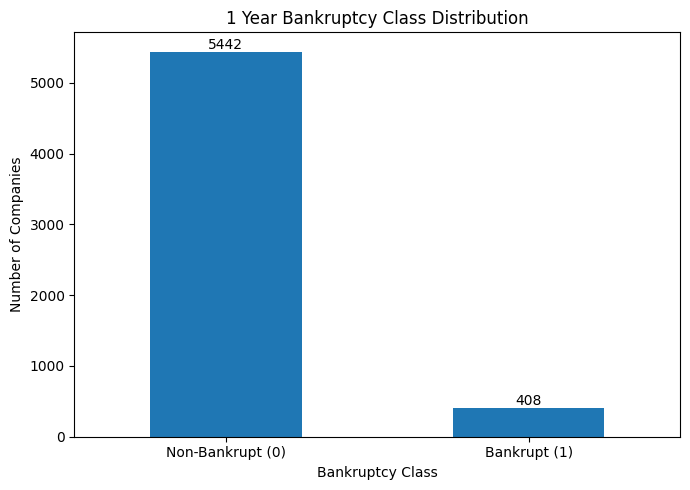

In [6]:
# Visualize the number of bankrupt and non-bankrupt companies 

fig, ax = plt.subplots(figsize=(7,5))

target_counts.plot(kind="bar", ax=ax)

ax.set_title("1 Year Bankruptcy Class Distribution")
ax.set_xlabel("Bankruptcy Class")
ax.set_ylabel("Number of Companies")
ax.set_xticklabels(["Non-Bankrupt (0)", "Bankrupt (1)"], rotation =0 )

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

## Target Distribution Observation

The cleaned dataset remains imbalanced. This imbalance means that accuracy alone will not be an appropriate model evaluation metric. Later modeling stages will emphasize metrics such as
recall, precision, F1-score, ROC-AUC, and especially PR-AUC

In [7]:
# Compare median financial ratios between bankrupt and non-bankrupt companies.

feature_columns = [
    col for col in bankruptcy_1y.columns
    if col != "class"
]

median_by_class = (bankruptcy_1y.groupby("class")[feature_columns].median().T)

median_by_class.columns = ["non_bankrupt_median", "bankrupt_median"]

median_by_class.head(15)

,non_bankrupt_median,bankrupt_median
X1,0.051841,-0.066961
X2,0.435900,0.724760
X3,0.232620,-0.013116
X4,1.711050,0.962060
X5,3.579000,-56.713500
X6,0.000000,-0.011849
X7,0.061870,-0.070960
X8,1.227500,0.354950
X9,1.141000,1.116500
X10,0.538245,0.254880


In [8]:
#Calculate the absolute difference between class medians

median_by_class["absolute_median_difference"] = (median_by_class["bankrupt_median"] - median_by_class["non_bankrupt_median"]).abs()

median_difference_ranking = (
    median_by_class.sort_values(
        "absolute_median_difference",
        ascending=False
    )
)

median_difference_ranking.head(15)

,non_bankrupt_median,bankrupt_median,absolute_median_difference
X55,2094.65000,-20.0250,2114.67500
X15,920.32500,-697.8050,1618.13000
X5,3.57900,-56.7135,60.29250
X62,71.64100,125.5400,53.89900
X32,78.47100,126.5200,48.04900
X44,59.08100,48.2280,10.85300
X47,42.39000,33.6640,8.72600
X27,1.01670,-1.2908,2.30750
X63,5.07555,2.8928,2.18275
X43,106.29000,104.5600,1.73000


In [9]:
# Calculate the IQR for each financial feature

feature_iqr = (
    bankruptcy_1y[feature_columns].quantile(0.75) - bankruptcy_1y[feature_columns].quantile(0.25)

)

feature_iqr.head()

X1     0.113189
X2     0.404850
X3     0.374803
X4     1.834500
X5    92.419500
dtype: float64

In [10]:
# Normalize the median difference by each feature's IQR

median_by_class["normalized_median_difference"] = (
    median_by_class["absolute_median_difference"] / feature_iqr.replace(0, np.nan)
)

normalized_median_ranking = (
    median_by_class.sort_values(by="normalized_median_difference", ascending=False)

)

normalized_median_ranking.head(15)

,non_bankrupt_median,bankrupt_median,absolute_median_difference,normalized_median_difference
X23,0.033159,-0.048515,0.081674,1.119374
X39,0.043255,-0.049856,0.093110,1.090763
X19,0.039648,-0.049486,0.089134,1.059354
X1,0.051841,-0.066961,0.118802,1.049585
X35,0.066144,-0.068973,0.135118,1.035054
X7,0.061870,-0.070960,0.132830,1.013664
X14,0.061903,-0.070960,0.132863,1.013645
X18,0.061903,-0.070960,0.132863,1.013645
X11,0.075942,-0.050269,0.126211,0.948933
X31,0.046803,-0.038768,0.085572,0.933835


### Median Comparison Note

Raw median differences are not directly comparable across features because financial ratios operate on very different numerical scales.

To improve comparability, the absolute median difference is normalized by each feature's interquartile range (IQR). This provides a scale-independent descriptive measure of separation between bankrupt and non-bankrupt companies.

In [11]:
# Select the six financial ratios with largest normalized median differences

top_features = (
    normalized_median_ranking.head(6).index.tolist()
)
top_features

['X23', 'X39', 'X19', 'X1', 'X35', 'X7']

In [12]:
# Define the financial meaning of the top six financial ratios based on the UCI dataset description

top_feature_descriptions = {
    "X23": "Net profit / sales",
    "X39": "Profit on sales / sales",
    "X19": "Gross profit / sales",
    "X1": "Net profit / total assets",
    "X35": "Profit on sales / total assets",
    "X7": "EBIT / total assets",
}

top_feature_summary = (
    normalized_median_ranking
    .loc[top_features]
    .reset_index()
    .rename(columns={"index": "feature"})
)

top_feature_summary["description"] = (
    top_feature_summary["feature"]
    .map(top_feature_descriptions)
)

top_feature_summary


,feature,non_bankrupt_median,bankrupt_median,absolute_median_difference,normalized_median_difference,description
0,X23,0.033159,-0.048515,0.081674,1.119374,Net profit / sales
1,X39,0.043255,-0.049856,0.093110,1.090763,Profit on sales / sales
2,X19,0.039648,-0.049486,0.089134,1.059354,Gross profit / sales
3,X1,0.051841,-0.066961,0.118802,1.049585,Net profit / total assets
4,X35,0.066144,-0.068973,0.135118,1.035054,Profit on sales / total assets
5,X7,0.061870,-0.070960,0.132830,1.013664,EBIT / total assets


In [13]:
# Create a visualization-only copy of the selected features. Values are clipped to the 1st and 99th percentiles only to improve boxplot readability. The original dataset used for modeling is unchanged.

plot_data = bankruptcy_1y[top_features + ["class"]].copy()

for feature in top_features:
    lower_bound = plot_data[feature].quantile(0.01)
    upper_bound = plot_data[feature].quantile(0.99)

    plot_data[feature] = plot_data[feature].clip(lower=lower_bound, upper=upper_bound)

plot_data.head(15)

,X23,X39,X19,X1,X35,X7,class
0,0.062287,0.095457,0.077287,0.088238,0.135230,0.109490,0
1,-0.004862,-0.028591,-0.004862,-0.006202,-0.036475,-0.006202,0
2,0.115280,0.129100,0.143490,0.130240,0.145860,0.162120,0
3,-0.070525,0.010998,-0.070525,-0.089951,0.014027,-0.089951,0
4,0.031802,0.240400,0.039129,0.048179,0.364200,0.059280,0
5,0.129260,0.184030,0.160590,0.231560,0.329680,0.287690,0
6,0.061722,0.083460,0.076897,0.099486,0.134520,0.123950,0
7,0.198920,0.191090,0.236590,0.078518,0.075428,0.093388,0
8,0.111750,0.167440,0.141590,0.125040,0.187360,0.158430,0
9,0.179190,0.015611,0.179190,0.293430,0.025565,0.293430,0


In [14]:
# Confirm that visualization clipping does not remove any observations.

print(f"Original dataset rows: {len(bankruptcy_1y):,}")
print(f"Plotting copy rows after clipping: {len(plot_data):,}")

Original dataset rows: 5,850
Plotting copy rows after clipping: 5,850


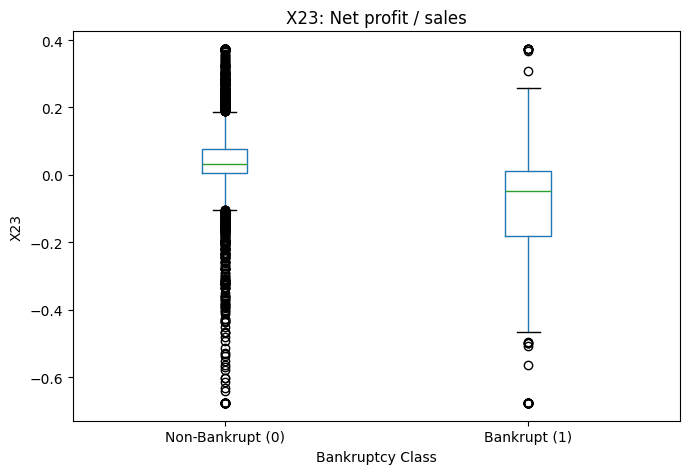

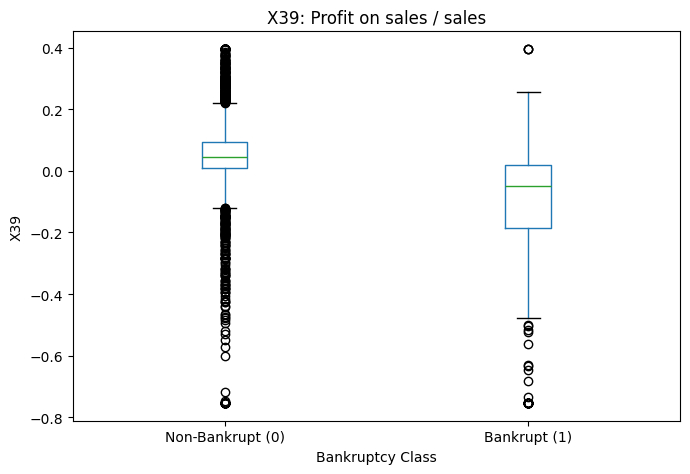

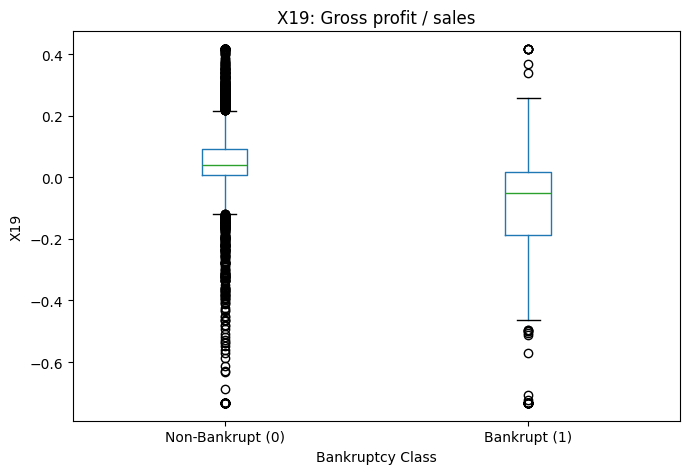

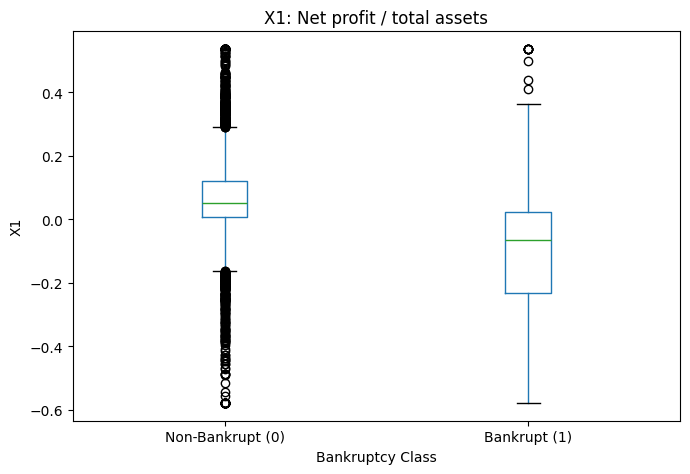

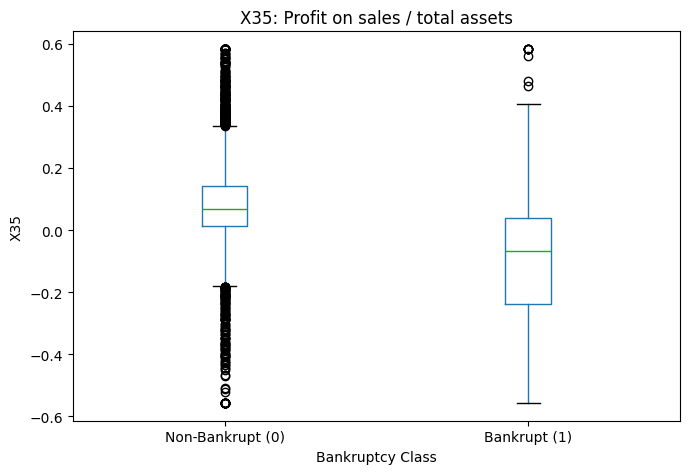

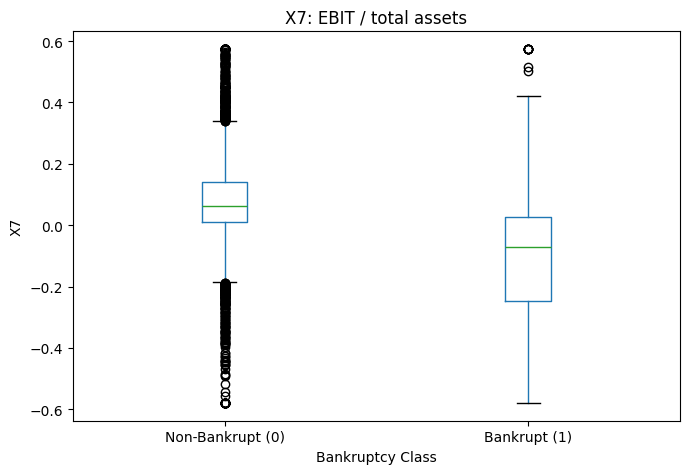

In [15]:
# Compare the distribution of the top six financial ratios between bankrupt and non-bankrupt companies using boxplots.

for feature in top_features:
    fig, ax = plt.subplots(figsize=(7,5))

    plot_data.boxplot(column=feature, by="class", ax=ax, grid=False)

    ax.set_title(f"{feature}: {top_feature_descriptions[feature]}")
    ax.set_xlabel("Bankruptcy Class")
    ax.set_ylabel(feature)
    ax.set_xticklabels(["Non-Bankrupt (0)", "Bankrupt (1)"])

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

In [16]:
#Display the class specific median values for the top six financial ratios

selected_medians = median_by_class.loc[top_features, ["non_bankrupt_median", "bankrupt_median"]]

selected_medians

,non_bankrupt_median,bankrupt_median
X23,0.033159,-0.048515
X39,0.043255,-0.049856
X19,0.039648,-0.049486
X1,0.051841,-0.066961
X35,0.066144,-0.068973
X7,0.061870,-0.070960


### Profitability Ratio Findings

The features showing largest IQR normalized difference are profitability related ratios across X23, X39, X19, X1, X35 and X7

- non_bankrupt companies have positive median ratios
- bankrupt companies have negative median ratios
- the direction of the difference is consistent across several related measures of profitability

These variables measure related financial concepts and may therefore be strongly correlated; their predictive contributions cannot be determined from median comparisons alone.

### Profitability Distribution Findings

Boxplots reinforce these findings based on median:

- Bankrupt companies show lower ratios
- Median profitability is negative for the bankrupt group across all six selected features, while it remains positive for non-bankrupt companies
- The class distributions still overlap substantially.
- Bankrupt companies generally show wider dispersion in several ratios and suggesting greater financial instability

These findings support profitability as an important bankruptcy risk signal

In [17]:
# Calculate Spearman correlation coefficients between the top six financial ratios to identify overlapping financial information.

profitability_corr = (
    bankruptcy_1y[top_features].corr(method="spearman")
)

profitability_corr.round(3)

,X23,X39,X19,X1,X35,X7
X23,1.000,0.744,0.986,0.925,0.706,0.911
X39,0.744,1.000,0.764,0.695,0.913,0.714
X19,0.986,0.764,1.000,0.912,0.726,0.922
X1,0.925,0.695,0.912,1.000,0.780,0.987
X35,0.706,0.913,0.726,0.780,1.000,0.802
X7,0.911,0.714,0.922,0.987,0.802,1.000


In [18]:
# Extract unique feature pairs from the correlation matrix to identify potential multicollinearity issues among the top six financial ratios.

correlation_pairs = (
    profitability_corr
    .where(np.triu(
        np.ones(profitability_corr.shape), k=1
    ).astype(bool)
    )
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "feature_1", "feature_2", "spearman_correlation"
]

correlation_pairs["absolute_correlation"] = (correlation_pairs["spearman_correlation"].abs())

correlation_pairs = correlation_pairs.sort_values(
    "absolute_correlation", ascending=False
)

correlation_pairs

,feature_1,feature_2,spearman_correlation,absolute_correlation
13,X1,X7,0.987433,0.987433
1,X23,X19,0.986172,0.986172
2,X23,X1,0.925379,0.925379
11,X19,X7,0.921928,0.921928
7,X39,X35,0.913118,0.913118
9,X19,X1,0.911513,0.911513
4,X23,X7,0.910546,0.910546
14,X35,X7,0.801529,0.801529
12,X1,X35,0.779865,0.779865
5,X39,X19,0.764217,0.764217


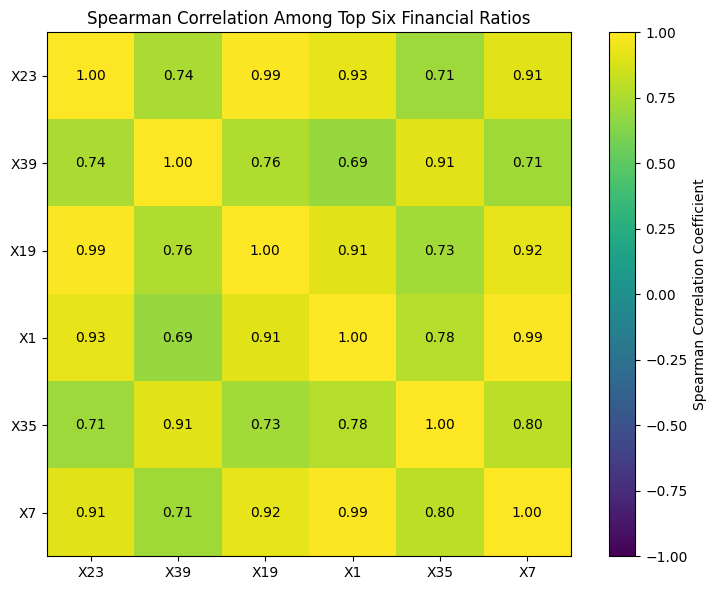

In [19]:
# Visualize Spearman correlations among the top six financial ratios.

fig, ax = plt.subplots(figsize=(8,6))

correlation_image = ax.imshow(
    profitability_corr,
    vmin= -1,
    vmax= 1
)

ax.set_xticks(range(len(top_features)))
ax.set_yticks(range(len(top_features)))

ax.set_xticklabels(top_features)
ax.set_yticklabels(top_features)

ax.set_title("Spearman Correlation Among Top Six Financial Ratios")

for i in range(len(top_features)):
    for j in range(len(top_features)):
        ax.text(
            j,
            i,
            f"{profitability_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(correlation_image, ax=ax, label="Spearman Correlation Coefficient")

plt.tight_layout()
plt.show()
       

In [20]:
# Count the number of missing financial values for each company to investigate the extent of missing data in the dataset.

feature_columns = [
    col for col in bankruptcy_1y.columns
    if col != "class"
]

bankruptcy_1y["missing_feature_count"] = (
    bankruptcy_1y[feature_columns]
    .isna()
    .sum(axis=1)
)

bankruptcy_1y[
    ["missing_feature_count", "class"]
].head()

,missing_feature_count,class
0,0,0
1,1,0
2,1,0
3,1,0
4,0,0


In [21]:
# Compare the amount of missing financial values between bankrupt and non-bankrupt companies 

missingness_by_class = (
    bankruptcy_1y
    .groupby("class")["missing_feature_count"]
    .agg(
        company_count="count",
        mean_missing_features="mean",
        median_missing_features="median",
        max_missing = "max"
    )
)

missingness_by_class.round(2)



,company_count,mean_missing_features,median_missing_features,max_missing
class,,,,
0,5442,0.73,0.0,41
1,408,1.58,1.0,28


In [22]:
# Compare bankruptcy rates between companies with missing values for financial features that actually contain missing data.

missingness_results = []

for feature in feature_columns:
    is_missing = bankruptcy_1y[feature].isna()

    if not is_missing.any():
        continue

    bankruptcy_rate_missing = (
        bankruptcy_1y.loc[
            is_missing,
            "class"
        ].mean()
    )

    bankruptcy_rate_present = (
        bankruptcy_1y.loc[
            ~is_missing,
            "class"
        ].mean()
    )

    missingness_results.append({
        "feature": feature,
        "missing_count": is_missing.sum(),
        "bankruptcy_rate_missing": bankruptcy_rate_missing,
        "bankruptcy_rate_present": bankruptcy_rate_present,
        "rate_difference": (
            bankruptcy_rate_missing
            - bankruptcy_rate_present
        )
    })

missingness_bankruptcy = pd.DataFrame(
    missingness_results
).sort_values(
    "rate_difference",
    ascending=False
)

missingness_bankruptcy.head(15)

,feature,missing_count,bankruptcy_rate_missing,bankruptcy_rate_present,rate_difference
17,X21,103,0.961165,0.053767,0.907398
1,X2,3,0.333333,0.069608,0.263725
2,X3,3,0.333333,0.069608,0.263725
6,X7,3,0.333333,0.069608,0.263725
5,X6,3,0.333333,0.069608,0.263725
16,X18,3,0.333333,0.069608,0.263725
12,X14,3,0.333333,0.069608,0.263725
10,X11,3,0.333333,0.069608,0.263725
9,X10,3,0.333333,0.069608,0.263725
39,X51,3,0.333333,0.069608,0.263725


In [23]:
#Convert bankruptcy rates to percentages for easier interpretation.

missingness_display = (missingness_bankruptcy.copy())

for column in ["bankruptcy_rate_missing", "bankruptcy_rate_present", "rate_difference"]:
    missingness_display[column] = (missingness_display[column] * 100).round(2)

missingness_display.head(15)


,feature,missing_count,bankruptcy_rate_missing,bankruptcy_rate_present,rate_difference
17,X21,103,96.12,5.38,90.74
1,X2,3,33.33,6.96,26.37
2,X3,3,33.33,6.96,26.37
6,X7,3,33.33,6.96,26.37
5,X6,3,33.33,6.96,26.37
16,X18,3,33.33,6.96,26.37
12,X14,3,33.33,6.96,26.37
10,X11,3,33.33,6.96,26.37
9,X10,3,33.33,6.96,26.37
39,X51,3,33.33,6.96,26.37


In [24]:
# Use a minimum of 30 missing observations to avoid interpreting highly unstable bankruptcy rates based on only a few companies.
MIN_MISSING_COUNT = 30

supported_missingness = (missingness_display[missingness_display["missing_count"] >= MIN_MISSING_COUNT].sort_values("rate_difference", ascending=False))

supported_missingness

,feature,missing_count,bankruptcy_rate_missing,bankruptcy_rate_present,rate_difference
17,X21,103,96.12,5.38,90.74
22,X27,390,31.54,5.22,26.32
23,X28,106,17.92,6.77,11.15
42,X54,106,17.92,6.77,11.15
48,X64,106,17.92,6.77,11.15
41,X53,106,17.92,6.77,11.15
45,X60,266,14.29,6.63,7.66
34,X45,266,14.29,6.63,7.66
30,X37,2525,8.28,5.98,2.29
25,X32,46,2.17,7.01,-4.84


In [25]:
# Build a table for X21 missingness and bankruptcy status to investigate the relationship between missing financial values and bankruptcy.

x21_missing_table = pd.crosstab(
    bankruptcy_1y["X21"].isna(),
    bankruptcy_1y["class"],
)

x21_missing_table.index = ["X21 Present", "X21 Missing"]

x21_missing_table.columns=["Non-Bankrupt", "Bankrupt"]

x21_missing_table 

,Non-Bankrupt,Bankrupt
X21 Present,5438,309
X21 Missing,4,99


In [26]:
# Summarize company counts, bankrupt counts and bankruptcy rates by X21 missingness status.

x21_missing_summary = (
    bankruptcy_1y.assign(
        x21_status = np.where(
            bankruptcy_1y["X21"].isna(),
            "X21 Missing",
            "X21 Present"
        )
    )
    .groupby("x21_status")["class"]
    .agg(
        company_count="count",
        bankrupt_count="sum",
        bankruptcy_rate="mean"
    )
)


x21_missing_summary["bankruptcy_rate"] = (
    x21_missing_summary["bankruptcy_rate"] * 100
).round(2)

x21_missing_summary

,company_count,bankrupt_count,bankruptcy_rate
x21_status,,,
X21 Missing,103,99,96.12
X21 Present,5747,309,5.38


In [27]:
# Import Fisher's exact test to determine if there is a significant association between missing financial values and bankruptcy.

from scipy.stats import fisher_exact

In [28]:
#Measure the association between X21 missingness and bankruptcy using Fisher's exact test.

x21_is_missing = bankruptcy_1y["X21"].isna()

contingency_table = pd.crosstab(
    x21_is_missing,
    bankruptcy_1y["class"]
).reindex(
    index=[True, False], columns=[1, 0], fill_value=0
)

odds_ratio, p_value = fisher_exact(contingency_table.values)

print(f"Odds Ratio: {odds_ratio:.2f}")
print(f"P-value: {p_value:.3e}")


Odds Ratio: 435.57
P-value: 6.049e-114


### Missingness Findings

Missing financial information is more common among bankrupt companies than among non-bankrupt companies.

The most notable case is X21. Companies with a missing X21 value show a much higher bankruptcy rate than companies for which X21 is observed.

Because this association is unusually strong, X21 missingness is treated as a potential predictive signal as well as a possible dataset-specific artifact that requires sensitivity analysis.

Features with only a small number of missing observations are not interpreted individually because their bankruptcy-rate estimates are unstable.


### Missingness and Bankruptcy Risk

Missing financial information is not evenly distributed across the two bankruptcy  class

The strongest relationship is seen in X21:

- 99 of the 103 companies with missing X21 values are bankrupt
- The bankruptcy rate is 96.12% when X21 is missing
- Fisher's exact test indicates an extremely strong association between X21 missingness and bankruptcy status

X27 and some other features also show higher rates when missing

In [29]:
#Calculate Spearman correlation between every financial feature and the target variable to identify features with strong monotonic relationships with bankruptcy.

feature_target_correlations = []

for feature in feature_columns:
    correlation = bankruptcy_1y[
        [feature, "class"]
    ].corr(method="spearman").loc[feature, "class"]

    feature_target_correlations.append({
        "feature": feature,
        "spearman_correlation": correlation,
        "absolute_correlation": abs(correlation)
    })

feature_target_correlation_df = pd.DataFrame(feature_target_correlations).sort_values("absolute_correlation", ascending=False)

feature_target_correlation_df.head(20)

,feature,spearman_correlation,absolute_correlation
25,X26,-0.259600,0.259600
15,X16,-0.258308,0.258308
38,X39,-0.253609,0.253609
12,X13,-0.250123,0.250123
34,X35,-0.246754,0.246754
11,X12,-0.244835,0.244835
44,X45,-0.244124,0.244124
22,X23,-0.239696,0.239696
18,X19,-0.238406,0.238406
30,X31,-0.235726,0.235726


In [30]:
#Display the features with the strongest positive relationships with bankruptcy based on the Spearman correlation coefficients.

strongest_positive = (
    feature_target_correlation_df[
        feature_target_correlation_df["spearman_correlation"] > 0
    ]
    .sort_values(
        "spearman_correlation",
        ascending=False
    )
)

strongest_positive

,feature,spearman_correlation,absolute_correlation
1,X2,0.190486,0.190486
57,X58,0.185928,0.185928
50,X51,0.184056,0.184056
61,X62,0.172621,0.172621
29,X30,0.158284,0.158284
31,X32,0.140076,0.140076
51,X52,0.126092,0.126092
60,X61,0.053641,0.053641
35,X36,0.020050,0.020050


In [31]:
#Display the features with the strongest negative relationships with bankruptcy based on the Spearman correlation coefficients.


strongest_negative = (
    feature_target_correlation_df
    .sort_values("spearman_correlation", ascending=True).head(10)
)

strongest_negative

,feature,spearman_correlation,absolute_correlation
25,X26,-0.259600,0.259600
15,X16,-0.258308,0.258308
38,X39,-0.253609,0.253609
12,X13,-0.250123,0.250123
34,X35,-0.246754,0.246754
11,X12,-0.244835,0.244835
44,X45,-0.244124,0.244124
22,X23,-0.239696,0.239696
18,X19,-0.238406,0.238406
30,X31,-0.235726,0.235726


In [32]:
# Select the 15 financial ratios with the strongest absolute Spearman correlation coefficients with bankruptcy to focus on the most relevant features for further analysis.

top_target_correlations= (
    feature_target_correlation_df
    .head(15)
    .sort_values("spearman_correlation")
)

top_target_correlations

,feature,spearman_correlation,absolute_correlation
25,X26,-0.259600,0.259600
15,X16,-0.258308,0.258308
38,X39,-0.253609,0.253609
12,X13,-0.250123,0.250123
34,X35,-0.246754,0.246754
11,X12,-0.244835,0.244835
44,X45,-0.244124,0.244124
22,X23,-0.239696,0.239696
18,X19,-0.238406,0.238406
30,X31,-0.235726,0.235726


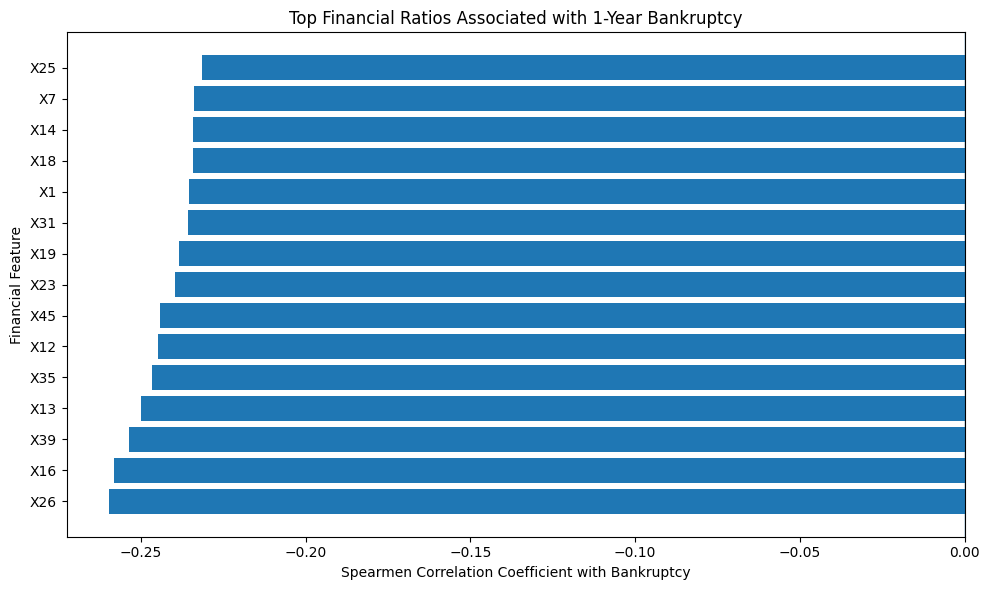

In [33]:
#Visualize the direction and magnitude of the strongest univariate relationships with the bankruptcy target

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(
    top_target_correlations["feature"],
    top_target_correlations["spearman_correlation"],
)

ax.set_title("Top Financial Ratios Associated with 1-Year Bankruptcy")

ax.set_xlabel("Spearmen Correlation Coefficient with Bankruptcy")
ax.set_ylabel("Financial Feature")
ax.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [34]:
# Create a temporary binary indicator for  X21 is missing this is used only to quantify the unusually strong missingness signal

bankruptcy_1y["X21_missing"] = (
    bankruptcy_1y["X21"]
    .isna()
    .astype(int)
)

x21_missing_correlation = (
    bankruptcy_1y[["X21_missing", "class"]]
    .corr(method="spearman")
    .loc["X21_missing", "class"]    
)

print(f"X21 missing indicator correlation with bankruptcy: {x21_missing_correlation:.3f}")

X21 missing indicator correlation with bankruptcy: 0.469


### Financial Ratio Relationships with Bankruptcy

The strongest univariate relationships with bankruptcy are primarily associated with profitability and debt-servicing capacity

Several profitability related ratios including X26, X16, X39, X35, X23, X19 and X1 show negative relationships with bankruptcy.

The strongest observed financial-feature correlations with the target are moderate rather than extreme. This suggests that bankruptcy risk is unlikely to be explained reliably by any single financial ratio and supports the use of multivariate predictive models.

The X21 missing value indicator  shows a stronger relationships with bankruptcy than any individual observed financial ratio.

## Exploratory Data Analysis Summary

### Class Imbalance

Only approximately 7% of companies are bankrupt, confirming a strongly imbalanced classification problem. Accuracy alone will not be sufficient for model evaluation.

### Profitability

The strongest IQR normalized median differences are concentrated among profitability related ratios.
Bankrupt companies show negative median profitability across several ratios, while non-bankrupt companies generally show positive median profitability.
The class distributions overlap substantially, indicating that bankruptcy cannot be identified reliably using any single profitability ratio.

### Feature Relationships

Some selected profitability ratios have Spearman correlations above 0.90, indicating substantial information overlap and potential multicollinearity.

### Missing Data

Missing financial information is more common among bankrupt companies.
X21 is particularly notable: 96.12% of companies with a missing X21 value are bankrupt, compared with 5.38% among companies where X21 is present.
X21 missingness will be treated both as a potentially useful predictive signal and as a possible dataset-specific artifact.

### Extreme Values

A lot of financial ratios are heavily skewed and contain  extreme observations. These values were not automatically removed because extreme financial ratios may arise naturally from small denominators or distressed company finances.
Robust preprocessing strategies will be evaluated during modeling.